In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
DATA_PATH = Path("../data/raw/ml-100k")

list(DATA_PATH.iterdir())[:10]

[PosixPath('../data/raw/ml-100k/u.item'),
 PosixPath('../data/raw/ml-100k/u3.test'),
 PosixPath('../data/raw/ml-100k/u1.base'),
 PosixPath('../data/raw/ml-100k/u.info'),
 PosixPath('../data/raw/ml-100k/u2.test'),
 PosixPath('../data/raw/ml-100k/u5.test'),
 PosixPath('../data/raw/ml-100k/u.genre'),
 PosixPath('../data/raw/ml-100k/ub.test'),
 PosixPath('../data/raw/ml-100k/ua.base'),
 PosixPath('../data/raw/ml-100k/u.data')]

In [4]:
ratings = pd.read_csv(
    DATA_PATH / "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [6]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [7]:
print("Users:", ratings["user_id"].nunique())
print("Movies:", ratings["movie_id"].nunique())
print("Ratings:", len(ratings))
print("Average rating:", ratings["rating"].mean())

Users: 943
Movies: 1682
Ratings: 100000
Average rating: 3.52986


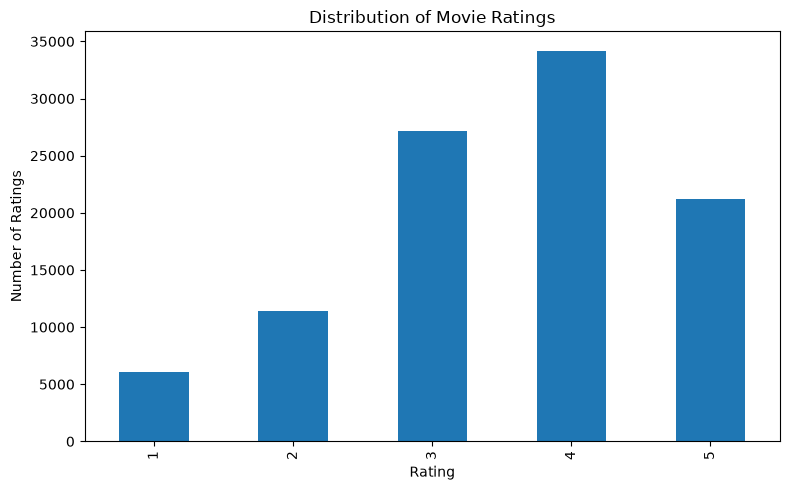

In [19]:
rating_counts = ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.tight_layout()

plt.savefig(
    "../results/figures/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
movies = pd.read_csv(
    DATA_PATH / "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["movie_id", "title"]
)

movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [10]:
df = ratings.merge(
    movies,
    on="movie_id"
)

df.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [11]:
most_rated = (
    df.groupby("title")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

most_rated

title
Star Wars (1977)                    583
Contact (1997)                      509
Fargo (1996)                        508
Return of the Jedi (1983)           507
Liar Liar (1997)                    485
English Patient, The (1996)         481
Scream (1996)                       478
Toy Story (1995)                    452
Air Force One (1997)                431
Independence Day (ID4) (1996)       429
Raiders of the Lost Ark (1981)      420
Godfather, The (1972)               413
Pulp Fiction (1994)                 394
Twelve Monkeys (1995)               392
Silence of the Lambs, The (1991)    390
dtype: int64

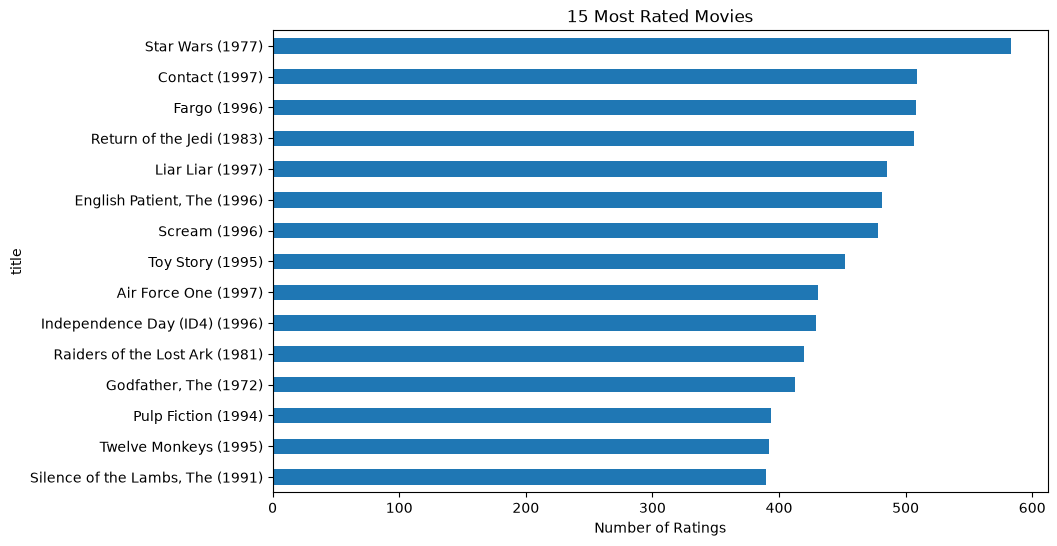

In [12]:
plt.figure(figsize=(10, 6))

most_rated.sort_values().plot(kind="barh")

plt.title("15 Most Rated Movies")
plt.xlabel("Number of Ratings")

plt.show()

In [13]:
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()

possible_ratings = num_users * num_movies
actual_ratings = len(ratings)

sparsity = 1 - (actual_ratings / possible_ratings)

print(f"Possible user-movie pairs: {possible_ratings:,}")
print(f"Observed ratings: {actual_ratings:,}")
print(f"Sparsity: {sparsity:.2%}")

Possible user-movie pairs: 1,586,126
Observed ratings: 100,000
Sparsity: 93.70%


In [14]:
ratings_per_user = ratings.groupby("user_id").size()

print(ratings_per_user.describe())

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64


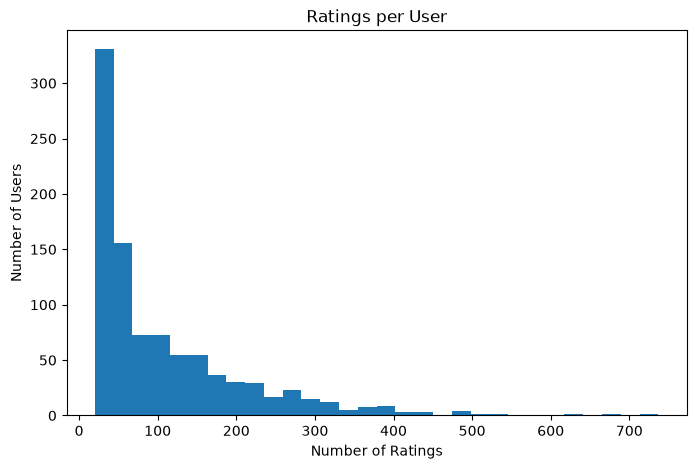

In [15]:
plt.figure(figsize=(8,5))

plt.hist(ratings_per_user, bins=30)

plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

In [16]:
movie_counts = (
    df.groupby("title")
      .size()
      .sort_values(ascending=False)
)

movie_counts.head(10)

title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
dtype: int64

In [17]:
rating_matrix = ratings.pivot(
    index="user_id",
    columns="movie_id",
    values="rating"
)

rating_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
rating_matrix.shape

(943, 1682)

## Key Findings

- The MovieLens 100K dataset contains 100,000 ratings from 943 users across 1,682 movies.
- The average rating is approximately 3.53 out of 5.
- The user-movie matrix is approximately 93.7% sparse, meaning most users have rated only a small fraction of the available movies.
- User activity varies substantially, with some users contributing far more ratings than others.
- Movie popularity is also uneven, with certain movies receiving significantly more ratings than others.

These characteristics make recommendation challenging: the system must infer user preferences from a highly sparse and unevenly distributed set of observed ratings.